# Clasificación CIFAR-10: Regresión Logística Multinomial 

60,000 imágenes RGB de 32×32 píxeles

## Fase 1 Preparacion del sistema

Cargar, procesar y prepararlos datos para el entrenamiento.

### 1.1 Cargar CIFAR-10

CIFAR-10 viene en 6 batches de entrenamiento (50k imagenes) y 1 de test (10k). Cada imagen es de 32x32x3 (RGB) que se aplana a `3072 valores`.

In [2]:
# import pandas as pd
# df = pd.DataFrame(X)
# df["label"] = y
# df.head()

In [3]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pickle
import matplotlib.pyplot as plt

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

ruta_cifar = '../Datasets/3_cifar-10-batches-py/'

# Cargar nombres de clases
meta = unpickle(ruta_cifar + 'batches.meta')
nombres_clases = [n.decode('utf-8') for n in meta[b'label_names']]
print("Clases:", nombres_clases)

# Cargar datos de entrenamiento (batches 1-5)
X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch = unpickle(f'{ruta_cifar}data_batch_{i}')
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train = np.vstack(X_train_list).astype(np.float32)
y_train = np.array(y_train_list, dtype=np.int64)

# Cargar datos de test
test_batch = unpickle(ruta_cifar + 'test_batch')
X_test = test_batch[b'data'].astype(np.float32)
y_test = np.array(test_batch[b'labels'], dtype=np.int64)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipykernel_44546/2957252368.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fo, encoding='bytes')


Train: (50000, 3072) | Test: (10000, 3072)


In [5]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

### 1.2 Visualizacion de muestras

Esto confirma que los datos se cargaron bien y muestran las 10 clases

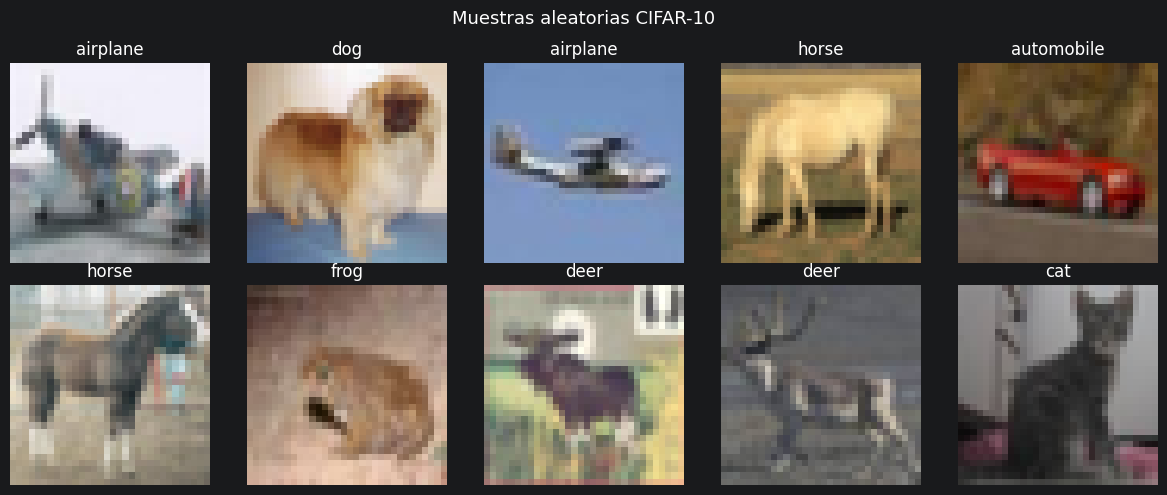

In [6]:
# Visualizar 10 muestras aleatorias
rng = np.random.default_rng(42)
indices = rng.choice(len(X_train), 30, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), indices):
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(nombres_clases[y_train[idx]])
    ax.axis('off')
plt.suptitle("Muestras aleatorias CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()

### 1.3 Split estratificado Train/Validacion

Split 40k train / 10k val / 10k test.

Estratificado para mantener procion de clases

In [7]:
# Split 80/20 estratificado por clase

rng2 = np.random.default_rng(42)
idx_tr, idx_val = [], []
for c in range(10):
    idx_c = rng2.permutation(np.where(y_train == c)[0])
    n_val = int(len(idx_c) * 0.2)
    idx_val.append(idx_c[:n_val])
    idx_tr.append(idx_c[n_val:])

idx_tr = np.concatenate(idx_tr); rng2.shuffle(idx_tr)
idx_val = np.concatenate(idx_val); rng2.shuffle(idx_val)

X_tr, y_tr = X_train[idx_tr] / 255.0, y_train[idx_tr]
X_val, y_val = X_train[idx_val] / 255.0, y_train[idx_val]
X_te = X_test / 255.0

# Normalización con media/std del train
mean_tr = X_tr.mean(axis=0)
std_tr = X_tr.std(axis=0) + 1e-8
print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}")

Train: (40000, 3072) | Val: (10000, 3072) | Test: (10000, 3072)


### 1.4 Dataset y DataLoader

CIFAR10Dataset hereda torch.utils.data.Dataset, normaliza en __init__ DataLoader maneja batches y shuffle

In [8]:
from torch.utils.data import Dataset, DataLoader

class CIFAR10Dataset(Dataset):
    """Dataset personalizado para CIFAR-10 con normalización media/std."""
    def __init__(self, X, y, mean=None, std=None):
        if mean is None: mean = X.mean(axis=0)
        if std is None: std = X.std(axis=0) + 1e-8
        X_norm = (X - mean) / std
        self.X = torch.tensor(X_norm, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

train_ds = CIFAR10Dataset(X_tr, y_tr, mean=mean_tr, std=std_tr)
val_ds   = CIFAR10Dataset(X_val, y_val, mean=mean_tr, std=std_tr)
test_ds  = CIFAR10Dataset(X_te, y_test, mean=mean_tr, std=std_tr)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches/epoch → train: {len(train_loader)} | val: {len(val_loader)}")

Batches/epoch → train: 157 | val: 40


### 1.5 Verificacion de DataLoader

In [9]:
# Prbar un batch 
xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape} | Batch y: {yb.shape}")
print(f"Valores X: min={xb.min():.3f}, max={xb.max():.3f}, mean={xb.mean():.3f}")
print(f"Clases en batch: {torch.unique(yb)}")

Batch X: torch.Size([256, 3072]) | Batch y: torch.Size([256])
Valores X: min=-2.204, max=2.619, mean=0.013
Clases en batch: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


## Fase 2 Arquitectua del modelo con `Sequential`

### 2.1 Componentes del modelo

`nn.Linear` -- La capa densa
Es la capa principal de un MLP. Hace una transformacion matematica:

$y=xW^T+b$

Donde `x` es la entrada, `W` son los pesos (lo que aprende) y `b` es el bias

In [10]:
nn.Linear(3072, 1024)

Linear(in_features=3072, out_features=1024, bias=True)

### 2.2 Modelo Completo

In [11]:
import torch
from torch import nn

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando: {DEVICE}")

modelo = nn.Sequential(
    # Bloque 1: 3072 → 1024
    nn.Linear(3072, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),

    # Bloque 2: 1024 → 512
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),

    # Bloque 3: 512 → 256
    nn.Linear(512, 256),
    nn.ReLU(),

    # Salida: 256 → 10 clases
    nn.Linear(256, 10)
)

print(modelo)

Usando: cuda
Sequential(
  (0): Linear(in_features=3072, out_features=1024, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=512, out_features=256, bias=True)
  (7): ReLU()
  (8): Linear(in_features=256, out_features=10, bias=True)
)


### 2.3 Contar parametros Entrenables

Resultado esperado alrededor de 3.9millones de parametros. Cada uno de esos es un numero que el modelo ajusta durante el entrenamiento para aprender a clasificar

In [12]:
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")

Parámetros entrenables: 3,805,450


### 2.4 Verificar que el modelo funciona

In [13]:
# Probar con un batch falso antes de entrenar con datos reales
x_prueba = torch.randn(8, 3072)  # 8 imágenes falsas
out = modelo(x_prueba)
print(f"Input:  {x_prueba.shape}")   # → torch.Size([8, 3072])
print(f"Output: {out.shape}")        # → torch.Size([8, 10])

Input:  torch.Size([8, 3072])
Output: torch.Size([8, 10])


## Fase 3 Entrenamiento

### 3.1 Función de pérdida y optimizador

`SGD` es el optimizador mas basico que existe: mueve los pesos en la direccion que reduce el error:

$w=w−lr×gradiente$

Nada mas. `lr=0.01` es el tamano del paso de correcion en cada batch

In [14]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=0.001)

### 3.2 El loop de entrenamiento

In [15]:
import os
import numpy as np
os.makedirs('./checkpoints', exist_ok=True)

EPOCHS    = 50
BEST_PATH = './checkpoints/mejor_modelo.pth'
best_val_acc = 0.0

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

modelo = modelo.to(DEVICE)

for epoch in range(1, EPOCHS + 1):

    # ── ENTRENAMIENTO ──────────────────────────────────────
    modelo.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        y_hat = modelo(xb)                              # forward
        loss  = criterion(y_hat, yb)                   # pérdida

        optimizer.zero_grad()                          # limpiar gradientes
        loss.backward()                                # calcular gradientes
        optimizer.step()                               # actualizar pesos

        train_loss    += loss.item() * xb.size(0)
        train_correct += (torch.argmax(y_hat, axis=1) == yb).sum().item()
        train_total   += yb.size(0)

    # ── VALIDACIÓN ─────────────────────────────────────────
    modelo.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            y_hat  = modelo(xb)
            loss   = criterion(y_hat, yb)
            val_loss    += loss.item() * xb.size(0)
            val_correct += (torch.argmax(y_hat, axis=1) == yb).sum().item()
            val_total   += yb.size(0)

    # ── MÉTRICAS ───────────────────────────────────────────
    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total * 100
    v_loss = val_loss  / val_total
    v_acc  = val_correct  / val_total  * 100

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    # ── BEST MODEL CHECKPOINT ──────────────────────────────
    # (04-pytorch_save.ipynb — "guardar modelo si es el mejor")
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(modelo.state_dict(), BEST_PATH)
        print(f"  ✓ Mejor modelo guardado (val_acc={v_acc:.2f}%)")

    print(f"Época {epoch:2d}/{EPOCHS} | "
          f"loss={t_loss:.4f}  acc={t_acc:.2f}% | "
          f"val_loss={v_loss:.4f}  val_acc={v_acc:.2f}%")

# ── CARGAR EL MEJOR MODELO AL FINAL ────────────────────────
# (04-pytorch_save.ipynb — "cargar el mejor modelo al final del entrenamiento")
modelo.load_state_dict(torch.load(BEST_PATH, weights_only=True))
print(f"\n✅ Listo. Mejor val_acc: {best_val_acc:.2f}%")

  ✓ Mejor modelo guardado (val_acc=13.20%)
Época  1/50 | loss=2.2990  acc=11.14% | val_loss=2.2954  val_acc=13.20%
  ✓ Mejor modelo guardado (val_acc=17.21%)
Época  2/50 | loss=2.2939  acc=13.11% | val_loss=2.2898  val_acc=17.21%
  ✓ Mejor modelo guardado (val_acc=19.93%)
Época  3/50 | loss=2.2886  acc=15.35% | val_loss=2.2839  val_acc=19.93%
  ✓ Mejor modelo guardado (val_acc=21.43%)
Época  4/50 | loss=2.2829  acc=17.39% | val_loss=2.2777  val_acc=21.43%
  ✓ Mejor modelo guardado (val_acc=22.36%)
Época  5/50 | loss=2.2771  acc=18.82% | val_loss=2.2710  val_acc=22.36%
  ✓ Mejor modelo guardado (val_acc=23.04%)
Época  6/50 | loss=2.2702  acc=20.32% | val_loss=2.2636  val_acc=23.04%
  ✓ Mejor modelo guardado (val_acc=23.47%)
Época  7/50 | loss=2.2633  acc=21.23% | val_loss=2.2554  val_acc=23.47%
  ✓ Mejor modelo guardado (val_acc=23.71%)
Época  8/50 | loss=2.2547  acc=22.24% | val_loss=2.2463  val_acc=23.71%
  ✓ Mejor modelo guardado (val_acc=24.05%)
Época  9/50 | loss=2.2458  acc=22.70%

## Fase 4 Validacion y ajuste

### 4.1 Curvas de Entrenamiento

| Lo que ves               | Qué significa                      |
| ------------------------ | ---------------------------------- |
| Train ↓ y Val ↓ juntas   | ✅ Modelo aprendiendo bien          |
| Train ↓ y Val se estanca | ⚠️ Sobreajuste comenzando          |
| Train ↓↓ y Val ↑         | ❌ Sobreajuste severo (overfitting) |
| Ambas altas y estancadas | ❌ Subajuste (underfitting)         |

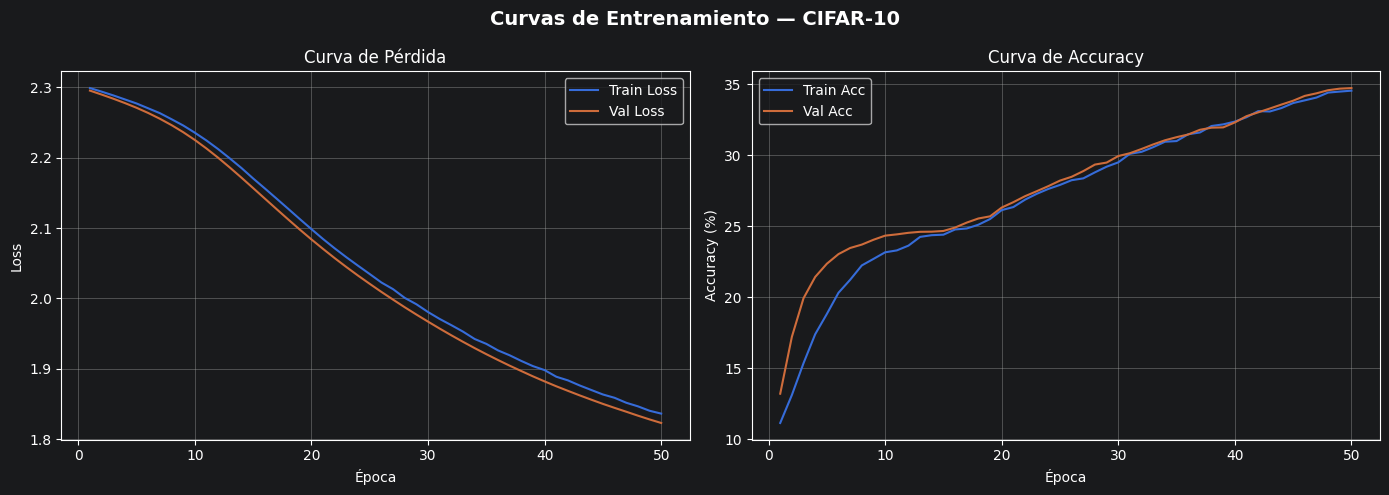

In [16]:
import matplotlib.pyplot as plt

epocas = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfica de Loss ──────────────────────────────────────
ax1.plot(epocas, history['train_loss'], label='Train Loss')
ax1.plot(epocas, history['val_loss'],   label='Val Loss')
ax1.set_title('Curva de Pérdida')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# ── Gráfica de Accuracy ──────────────────────────────────
ax2.plot(epocas, history['train_acc'], label='Train Acc')
ax2.plot(epocas, history['val_acc'],   label='Val Acc')
ax2.set_title('Curva de Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Curvas de Entrenamiento — CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Evaluacion final en test

Cargamos el mejor modelo con load_state_disct, no el ultimo. Le ultimo puede estar sobreajustado, el mejor es el que tuvo mayor val_acc durante todo el entrenamiento

In [17]:
# Cargar el MEJOR modelo (no el último)
best_model = nn.Sequential(
    nn.Linear(3072, 1024), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(1024, 512),  nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.ReLU(),
    nn.Linear(256, 10)
)
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
best_model.eval()
best_model = best_model.to(DEVICE)

# Evaluar en test
test_correct, test_total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = best_model(xb)
        test_correct += (torch.argmax(logits, axis=1) == yb).sum().item()
        test_total   += yb.size(0)

test_acc = test_correct / test_total * 100
print(f"✅ Accuracy en Test: {test_acc:.2f}%")

✅ Accuracy en Test: 35.42%


### 4.3 Visualizar predicciones reales

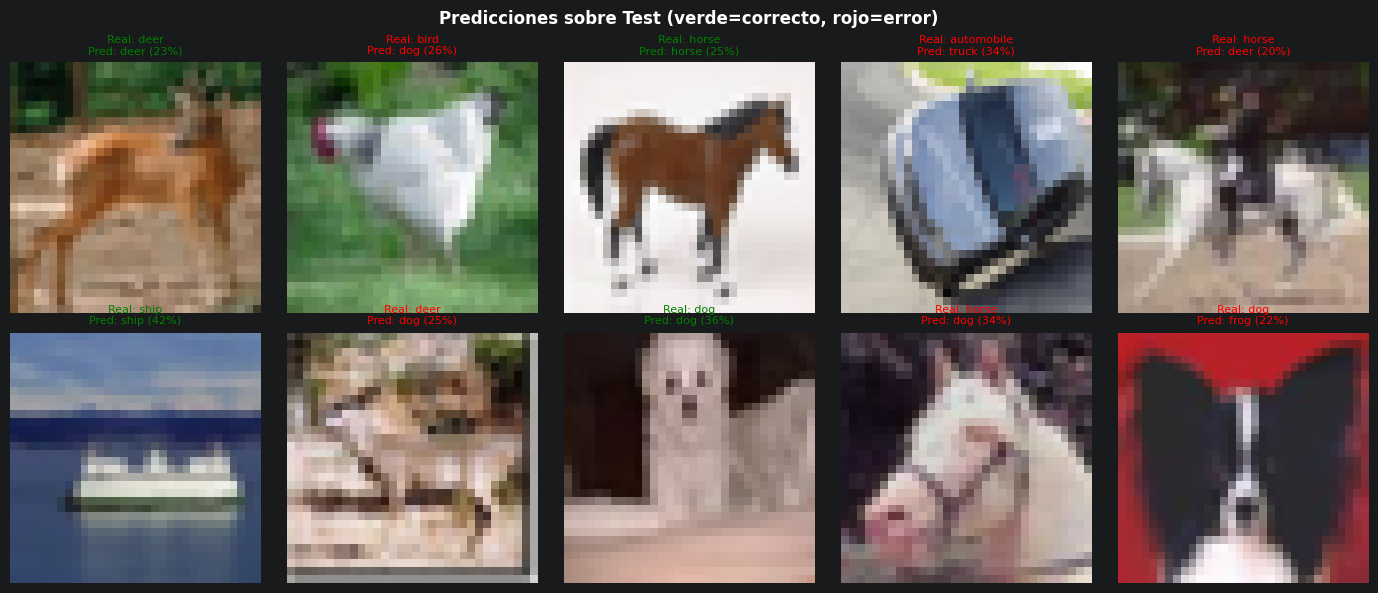

In [18]:
rng_prueba = np.random.default_rng(99)
idx_prueba = rng_prueba.choice(len(X_te), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, idx in zip(axes.flatten(), idx_prueba):
    # Imagen original (solo /255, sin normalización para visualizar)
    img = X_te[idx].reshape(3, 32, 32).transpose(1, 2, 0)

    # Preprocesar con la normalización del entrenamiento
    x_norm  = (X_te[idx] - mean_tr) / std_tr
    x_input = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    # Predicción
    with torch.no_grad():
        probs      = torch.softmax(best_model(x_input), dim=1)[0]
        pred_idx   = probs.argmax().item()
        pred_nombre = nombres_clases[pred_idx]
        confianza  = probs[pred_idx].item() * 100

    real_nombre  = nombres_clases[y_test[idx]]
    color_titulo = 'green' if pred_idx == y_test[idx] else 'red'

    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(
        f"Real: {real_nombre}\nPred: {pred_nombre} ({confianza:.0f}%)",
        fontsize=8, color=color_titulo
    )
    ax.axis('off')

plt.suptitle("Predicciones sobre Test (verde=correcto, rojo=error)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Fase 5 Pruebafinal y exportacion

---
## Definiciones Auxiliares

Las siguientes clases y funciones son necesarias para las secciones 5 y 6.

In [19]:
from torch import nn

class MLP_CIFAR10(nn.Module):
    """MLP con BatchNorm y Dropout para CIFAR-10."""
    def __init__(self, in_features=3072, num_classes=10):
        super().__init__()
        self.fc1   = nn.Linear(in_features, 1024)
        self.bn1   = nn.BatchNorm1d(1024)
        self.act1  = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.fc2   = nn.Linear(1024, 512)
        self.bn2   = nn.BatchNorm1d(512)
        self.act2  = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        self.fc3  = nn.Linear(512, 256)
        self.act3 = nn.ReLU()
        self.out  = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.drop1(self.act1(self.bn1(self.fc1(x))))
        x = self.drop2(self.act2(self.bn2(self.fc2(x))))
        x = self.act3(self.fc3(x))
        return self.out(x)

model_demo = MLP_CIFAR10()
total_params = sum(p.numel() for p in model_demo.parameters() if p.requires_grad)
print(f"MLP_CIFAR10 definida ✓  |  Parámetros entrenables: {total_params:,}")


MLP_CIFAR10 definida ✓  |  Parámetros entrenables: 3,808,522


In [20]:
import os
import torch
from torch import nn

def fit(model, train_loader, val_loader,
        epochs=5, lr=1e-3,
        best_path='./checkpoints/best_model.pth',
        resume_path='./checkpoints/resume_checkpoint.pth',
        backup_every=5,
        device='cpu'):
    """Loop de entrenamiento con best-model + resume-from-checkpoint."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    start_epoch = 1
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    if resume_path and os.path.exists(resume_path):
        print(f"▶ Reanudando entrenamiento desde: {resume_path}")
        ckpt = torch.load(resume_path, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch  = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_val_acc']
        history      = ckpt['history']
        print(f"   → Continuando desde época {start_epoch} | mejor val_acc: {best_val_acc:.2f}%")
    else:
        print("▶ Entrenamiento desde cero.")

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * xb.size(0)
            t_correct += (logits.argmax(1) == yb).sum().item()
            t_total   += yb.size(0)
        scheduler.step()

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss   = criterion(logits, yb)
                v_loss    += loss.item() * xb.size(0)
                v_correct += (logits.argmax(1) == yb).sum().item()
                v_total   += yb.size(0)

        tl = t_loss / t_total;  ta = t_correct / t_total * 100
        vl = v_loss / v_total;  va = v_correct / v_total * 100
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), best_path)
            print(f"   ✓ Mejor modelo guardado (val_acc={va:.2f}%)")

        if epoch % backup_every == 0:
            ckpt = {
                'epoch': epoch, 'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'history': history, 'best_val_acc': best_val_acc,
            }
            torch.save(ckpt, resume_path)
            print(f"   💾 Backup guardado (época {epoch}/{epochs})")

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"loss={tl:.4f} acc={ta:.2f}% | "
              f"val_loss={vl:.4f} val_acc={va:.2f}%")

    model.load_state_dict(torch.load(best_path, weights_only=True))
    print(f"\n✅ Entrenamiento finalizado. Mejor val_acc: {best_val_acc:.2f}%")
    return history

print("Función fit() definida ✓")


Función fit() definida ✓


### 5.1 Guardar el modelo completo

Guarda arquitectura + pesos en un solo archivo con torch.save(model, path)

In [21]:
# Guardar
torch.save(modelo, './checkpoints/mlp_completo.pt')

# Cargar — NO necesitas la arquitectura explícita, pero sí la clase definida
model_full = torch.load('./checkpoints/mlp_completo.pt', weights_only=False)
model_full.eval()
print('Modelo completo cargado ✓')

Modelo completo cargado ✓


### 5.2 Best-Model Checkpoint (guardar si mejora)

Dentro de `fit()`, se guarda solo cuando la validacion mejora y se carga el mejor modelo al terminar:

In [29]:
best_acc = 0

EPOCHS = 5  # ejemplo ilustrativo
for epoch in range(1, EPOCHS + 1):
    # ... entrenamiento y validación ...

    # Guardar SOLO si mejora
    val_acc = 0.0  # placeholder
if val_acc > best_acc:
        best_acc = val_acc
        torch.save(modelo.state_dict(), PATH)
        print(f"✓ Mejor modelo guardado (val_acc={val_acc:.2f}%)")

# Al final: cargar el mejor (no el último)
modelo.load_state_dict(torch.load(PATH, weights_only=True))

NameError: name 'PATH' is not defined

## Fase 6 Trabajo real

### CIFAR-10 viene en 5 archivos binarios de entrenamiento + 1 de test:

In [28]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

ruta_cifar = '../Datasets/3_cifar-10-batches-py/'

meta = unpickle(ruta_cifar + 'batches.meta')
nombres_clases = [n.decode('utf-8') for n in meta[b'label_names']]
# → ['airplane', 'automobile', 'bird', 'cat', 'deer',
#    'dog', 'frog', 'horse', 'ship', 'truck']

X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch = unpickle(f'{ruta_cifar}data_batch_{i}')
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train = np.vstack(X_train_list).astype(np.float32)  # (50000, 3072)
y_train = np.array(y_train_list, dtype=np.int64)

test_batch = unpickle(ruta_cifar + 'test_batch')
X_test = test_batch[b'data'].astype(np.float32)        # (10000, 3072)
y_test = np.array(test_batch[b'labels'], dtype=np.int64)

/tmp/ipykernel_44546/725151802.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fo, encoding='bytes')


## Split Estratificado Train / Val

In [27]:
rng2 = np.random.default_rng(42)
idx_tr, idx_val = [], []

for c in range(10):               # por cada una de las 10 clases
    idx_c = rng2.permutation(np.where(y_train == c)[0])
    n_val = int(len(idx_c) * 0.2) # 20% para validación
    idx_val.append(idx_c[:n_val])
    idx_tr.append(idx_c[n_val:])

idx_tr  = np.concatenate(idx_tr);  rng2.shuffle(idx_tr)
idx_val = np.concatenate(idx_val); rng2.shuffle(idx_val)

# Normalizar a [0, 1] dividiendo por 255
X_tr,  y_tr  = X_train[idx_tr]  / 255.0, y_train[idx_tr]
X_val, y_val = X_train[idx_val] / 255.0, y_train[idx_val]
X_te         = X_test            / 255.0

# Media y std solo del train (no contaminar val/test)
mean_tr = X_tr.mean(axis=0)
std_tr  = X_tr.std(axis=0) + 1e-8
# → Train: (40000, 3072) | Val: (10000, 3072) | Test: (10000, 3072)

### Datasets y DataLoaders

In [26]:
BATCH_SIZE = 256

train_ds = CIFAR10Dataset(X_tr,  y_tr,  mean=mean_tr, std=std_tr)
val_ds   = CIFAR10Dataset(X_val, y_val, mean=mean_tr, std=std_tr)
test_ds  = CIFAR10Dataset(X_te,  y_test, mean=mean_tr, std=std_tr)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
# → Batches/epoch → train: 157 | val: 40

### Modelo y Dispositivo

In [25]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")  # → cuda (en el lab)

model = MLP_CIFAR10(in_features=3072, num_classes=10)
# → Parámetros: 3,808,522

Dispositivo: cuda


### Entrenamiento con Dual Checkpoint

In [24]:
EPOCHS     = 50
BEST_PATH  = './checkpoints/best_cifar10.pth'
RESUME_PATH= './checkpoints/resume_checkpoint.pth'

history = fit(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    lr           = 1e-3,
    best_path    = BEST_PATH,
    resume_path  = RESUME_PATH,
    backup_every = 5,   # backup cada 5 épocas
    device       = DEVICE
)

NameError: name 'model' is not defined

### Predicciones sobre X_test

In [ ]:
best_model = MLP_CIFAR10(in_features=3072, num_classes=10)
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
best_model.eval()
best_model.to(DEVICE)

rng_prueba = np.random.default_rng(99)
idx_prueba = rng_prueba.choice(len(X_te), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flatten(), idx_prueba):
    img    = X_te[idx].reshape(3, 32, 32).transpose(1, 2, 0)
    x_norm = (X_te[idx] - mean_tr) / std_tr
    x_in   = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs     = torch.softmax(best_model(x_in), dim=1)[0]
        pred_idx  = probs.argmax().item()
        confianza = probs[pred_idx].item() * 100

    color = 'green' if pred_idx == y_test[idx] else 'red'
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"Real: {nombres_clases[y_test[idx]]}\n"
                 f"Pred: {nombres_clases[pred_idx]} ({confianza:.0f}%)",
                 fontsize=8, color=color)
    ax.axis('off')
plt.tight_layout(); plt.show()

### Tu propia imagen

In [ ]:
from PIL import Image
import tkinter as tk
from tkinter import filedialog

root = tk.Tk(); root.withdraw()
ruta = filedialog.askopenfilename(
    title="Selecciona una imagen",
    filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp *.webp")]
)
root.destroy()

# Preprocesar: resize a 32×32, flatten, normalizar
img_pil   = Image.open(ruta).convert('RGB').resize((32, 32))
img_flat  = np.array(img_pil, dtype=np.float32) / 255.0
img_flat  = img_flat.transpose(2, 0, 1).flatten()    # (3072,)
img_norm  = (img_flat - mean_tr) / std_tr
x_in      = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    probs      = torch.softmax(best_model(x_in), dim=1)[0]
    clase_idx  = probs.argmax().item()
    confianza  = probs[clase_idx].item() * 100

print(f"Predicción: {nombres_clases[clase_idx].upper()} ({confianza:.1f}%)")